In [1]:
import networkx as nx
import numpy as np
import torch
from src.dataset import NIMDatasetHandler
from torch import nn

import decent_bench.algorithms.decentralized as dec_algorithms
import decent_bench.utils.interoperability as iop
from decent_bench import benchmark
from decent_bench.agents import Agent
from decent_bench.algorithms.utils import pytorch_initialization
from decent_bench.costs import PyTorchCost
from decent_bench.metrics import metric_library as ml
from decent_bench.metrics import runtime_library
from decent_bench.networks import P2PNetwork
from decent_bench.utils.checkpoint_manager import CheckpointManager
from decent_bench.utils.pytorch_utils import SimpleLinearModel
from decent_bench.utils.types import SupportedDevices
from examples.nim.src.algorithms.lt_admm_ema import LT_ADMM_EMA
from examples.nim.src.algorithms.lt_admm_torch_optimizer import LT_ADMM_TORCH


In [2]:
cm = CheckpointManager("results/nim/5_4/test_None_True/diverged/LT-ADMM")
result = cm.load_benchmark_result()


In [8]:
for alg, networks in result.states.items():
    for network in networks:
        for agent in network.agents():
            if not isinstance(agent.cost, PyTorchCost):
                continue
            for i, x in agent._x_history.items():
                print(i, x)
            break
        break
    break

0 tensor([-0.6321, -0.6365, -0.0457,  ...,  0.0445,  0.0535,  0.0891],
       device='cuda:0')
500 tensor([nan, nan, nan,  ..., nan, nan, nan], device='cuda:0')
1000 tensor([nan, nan, nan,  ..., nan, nan, nan], device='cuda:0')
1500 tensor([nan, nan, nan,  ..., nan, nan, nan], device='cuda:0')
2000 tensor([nan, nan, nan,  ..., nan, nan, nan], device='cuda:0')
2500 tensor([nan, nan, nan,  ..., nan, nan, nan], device='cuda:0')
3000 tensor([nan, nan, nan,  ..., nan, nan, nan], device='cuda:0')
3500 tensor([nan, nan, nan,  ..., nan, nan, nan], device='cuda:0')
4000 tensor([nan, nan, nan,  ..., nan, nan, nan], device='cuda:0')
4500 tensor([nan, nan, nan,  ..., nan, nan, nan], device='cuda:0')
5000 tensor([nan, nan, nan,  ..., nan, nan, nan], device='cuda:0')
5500 tensor([nan, nan, nan,  ..., nan, nan, nan], device='cuda:0')
6000 tensor([nan, nan, nan,  ..., nan, nan, nan], device='cuda:0')
6500 tensor([nan, nan, nan,  ..., nan, nan, nan], device='cuda:0')
7000 tensor([nan, nan, nan,  ..., n

[04/07/26 20:41:36] INFO     No checkpoint manager provided, running benchmark without            ]8;id=907699;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=472645;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#267\267]8;;\
                             checkpointing. Progress cannot be resumed if interrupted.                             

                    INFO     Starting benchmark execution                                         ]8;id=256769;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=149649;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#353\353]8;;\

Output()

[04/07/26 20:48:10] INFO     Benchmark execution complete, thanks for using decent-bench          ]8;id=61181;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=688437;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#371\371]8;;\

Output()

[04/07/26 20:48:11] WARNING  No table metrics to display.                                             ]8;id=802095;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=14064;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#55\55]8;;\

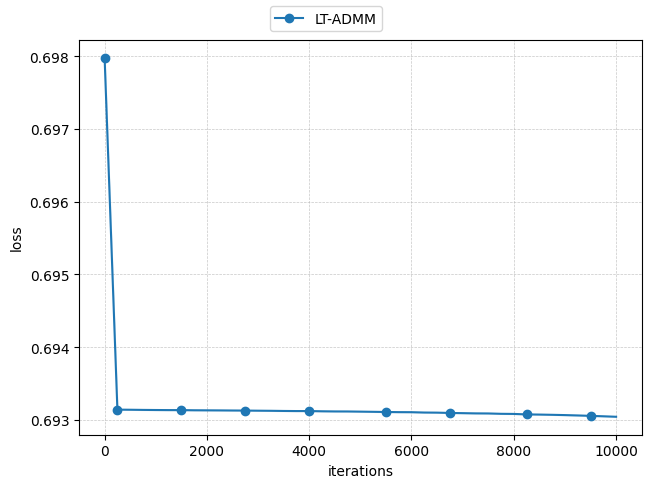

In [2]:
iterations = 10_000
state_snapshot_period = 250
samples_per_partition = 2000
test_samples = 10_000
leakage = 0.0
label_balance = 2.0
image_file = "data/kth_floorplan_sample.png"
batch_size = 64
device = SupportedDevices.CPU
opt_cls = torch.optim.Adam

table_metrics = [
    ml.ConsensusError([min, np.average, max]),
    ml.GradientCalls([np.average, sum]),
    ml.SentMessages([np.average, sum]),
    ml.MSE([min, np.average, max]),
    ml.Loss([min, np.average, max]),
]

plot_metrics = [
    # [ml.ConsensusError([], x_log=False, y_log=True)],
    # [ml.MSE([], x_log=False, y_log=True)],
    [ml.Loss([], x_log=False, y_log=False)],
]


def model_generator() -> torch.nn.Module:
    """Generate a simple linear model for the NIM dataset."""
    return SimpleLinearModel(
        input_size=2,
        hidden_sizes=[32, 64, 64, 32, 16],
        output_size=1,
    )


class FinalActivation(nn.Module):  # noqa: D101
    def __init__(self, threshold: float = 0.5):
        super().__init__()
        self.sigmoid = nn.Sigmoid()
        self.threshold = threshold

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # noqa: D102
        return (self.sigmoid(x) > self.threshold).long()


iop.set_seed(47)
train_dataset = NIMDatasetHandler(
    image_file=image_file,
    n_partitions=5,
    samples_per_partition=samples_per_partition,
    transform=torch.tensor,  # type: ignore[arg-type]
    label_transform=lambda x: torch.tensor(x, dtype=torch.float32).unsqueeze(0),  # type: ignore[arg-type]
    label_balance=label_balance,
    leakage=leakage,
)

costs = [
    PyTorchCost(
        dataset=p,
        model=model_generator(),
        loss_fn=nn.BCEWithLogitsLoss(),
        final_activation=FinalActivation(threshold=0.5),
        batch_size=batch_size,
        max_batch_size=batch_size * 4,
        device=device,
    )
    for p in train_dataset.get_partitions()
]
agents = [
    Agent(
        i,
        cost,
        state_snapshot_period=state_snapshot_period,
    )
    for i, cost in enumerate(costs)
]
graph = nx.random_regular_graph(d=4, n=5, seed=iop.get_seed())
network = P2PNetwork(
    graph=graph,
    agents=agents,
)
problem = benchmark.BenchmarkProblem(
    network=network,
    test_data=train_dataset.get_test_set(label_balance=1.0, num_samples=test_samples),
)
x0 = pytorch_initialization(network, all_same=True)
algorithms = [
    # dec_algorithms.DGD(
    #     step_size=0.05,
    #     aux_step_size=1.0,
    #     iterations=iterations,
    #     x0=x0,
    # ),
    dec_algorithms.LT_ADMM(
        iterations=iterations,
        local_steps=10,
        step_size=0.01,
        aux_step_size=0.01,
        penalty=1.0,
        mask_z=False,
        x0=x0,
    )
]

result = benchmark.benchmark(
    algorithms=algorithms,
    benchmark_problem=problem,
    n_trials=1,
    show_speed=True,
    show_trial=True,
)

metric_result = benchmark.compute_metrics(
    benchmark_result=result,
    table_metrics=[],
    plot_metrics=plot_metrics,
)

benchmark.display_metrics(
    metrics_result=metric_result,
    show_plots=True,
)


Results for LT-ADMM, 1 trials


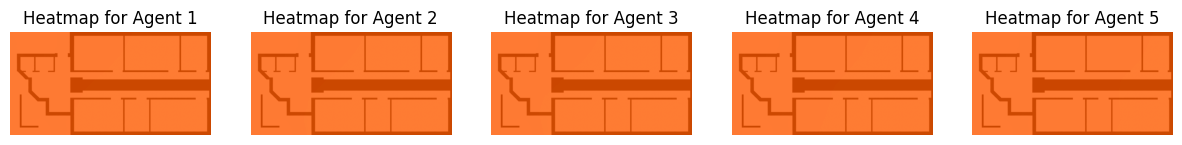

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch import nn

from decent_bench.networks import Network
from decent_bench.utils.checkpoint_manager import CheckpointManager


class FinalActivation(nn.Module):  # noqa: D101
    def __init__(self, threshold: float = 0.5):
        super().__init__()
        self.sigmoid = nn.Sigmoid()
        self.threshold = threshold

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # noqa: D102
        return (self.sigmoid(x) > self.threshold).long()


def heatmap_plot(
    network: Network,
    width: int,
    height: int,
    norm: float,
) -> list[list[float]]:
    xs = np.arange(0, width) / norm
    ys = np.arange(0, height) / norm
    X, Y = np.meshgrid(xs, ys, indexing="xy")
    nx, ny = X.shape
    points = np.column_stack((X.ravel(), Y.ravel()))
    # points = np.random.default_rng().choice(points, size=10_000, replace=False)
    mats = []
    for agent in network.agents():
        agent_activation = agent.cost.final_activation
        agent.cost.final_activation = nn.Sigmoid()
        out = agent.cost.predict(agent.x, torch.tensor(points, dtype=torch.float32))
        agent.cost.final_activation = agent_activation
        out_np = np.array(out)

        mats.append(out_np.reshape((nx, ny)))

    return mats


image = Image.open("data/kth_floorplan_sample.png").convert("L")
image_array = np.array(image)
height, width = image_array.shape
feature_norm = max(height, width)


for alg, networks in result.states.items():
    print(f"Results for {alg.name}, {len(networks)} trials")
    for n in networks:
        heatmaps = heatmap_plot(n, width, height, feature_norm)
        fig, ax = plt.subplots(1, 5, figsize=(15, 10))
        for i, map in enumerate(heatmaps):
            ax[i].imshow(image_array, cmap="gray")
            ax[i].imshow(map, cmap="hot", interpolation="nearest", vmin=0, vmax=1, alpha=0.8)
            ax[i].invert_yaxis()
            ax[i].axis("off")
            ax[i].set_title(f"Heatmap for Agent {i + 1}")
        plt.show()

# for cp in Path(r"/home/ubuntu/github/decent-bench/examples/nim/results/nim/5_4/test_None_None_None_None").iterdir():
#     cm = CheckpointManager(cp)
#     result = cm.load_benchmark_result()

#     for alg, networks in result.states.items():
#         print(f"Results for {alg.name}, {len(networks)} trials")
#         for n in networks:
#             heatmaps = heatmap_plot(n, width, height, feature_norm)
#             fig, ax = plt.subplots(1, 5, figsize=(15, 10))
#             for i, map in enumerate(heatmaps):
#                 ax[i].imshow(image_array, cmap="gray")
#                 ax[i].imshow(map, cmap="hot", interpolation="nearest", vmin=0, vmax=1, alpha=0.8)
#                 ax[i].invert_yaxis()
#                 ax[i].axis("off")
#                 ax[i].set_title(f"Heatmap for Agent {i + 1}")
#             plt.show()